<div style="background-color: #F4F6F7; padding: 20px; border-radius: 8px; font-family: 'Arial', sans-serif; color: #2E4053;">
  <!-- Logo centrado -->
  <div style="text-align: center; margin-bottom: 15px;">
    <img src="https://drive.google.com/uc?export=view&id=1kjzXfjTiieYAd4azw5bh4UfEg91gUIdh" alt="Logo Institucional" width="250" />
  </div>

  <!-- Título principal -->
  <h1 style="font-size: 36px; font-weight: bold; text-align: right;">
    <strong>Estimación del gradiente geotérmico a partir de imágenes multiespectrales del LANDSAT 7 y base de datos tabular mediante un sistema con atención intramodal e intermodal residual, además de weighted sampler, selección de variables y clipping de atípicos</strong>
  </h1>

  <!-- Datos del estudiante -->
  <p style="font-size: 22px; text-align: center; margin: 5px 0;">
    <strong>Pereira, 2026</strong> &nbsp;|&nbsp;
    <strong>Institución:</strong> Universidad Tecnológica de Pereira  &nbsp;|&nbsp;
    <strong>Grupo de investigación en Automática </strong>
  </p>

  <hr style="border: 1px solid #ABB2B9; margin: 10px 0;" />

  <!-- Descripción breve -->
  <p style="font-size: 18px; text-align: center; font-style: italic; margin: 5px 0;">
    Este cuaderno es la primera prueba donde se entrena un modelo multimodal mediante el uso de imágenes satelitales multiespectrales del LANDSAT7 y una base de datos que contienen diversas variables geológicas y geofísicas para estimar el gradiente geotérmico en Colombia. Incluye: ingestión y preprocesado de mosaicos (manejo de NoData), creación de muestras/parches, estrategia de fine-tuning, evaluación con métricas de regresión R2, MAE y RMSE y exportación de predicciones y checkpoints para análisis geoespacial.

  </p>

  <hr style="border: 1px solid #ABB2B9; margin: 10px 0;" />
</div>


# **1. Carga de las librerías, imágenes y la base de datos**

In [1]:
!pip install -q --upgrade pip
!pip install -q rasterio==1.4 pyproj rioxarray
!pip install -q torchvision tqdm scikit-image pandas
!pip install torch-optimizer
import warnings
warnings.filterwarnings(
    "ignore",
    message="This overload of addcmul_ is deprecated"
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 24.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torch-optimizer]


In [2]:
!gdown 1OIJY8QtxRYr4HW504Awxama22OAuBJID # Base de datos cruda
#!gdown 1oZAsFy_yDXnJUbUQbuIMlIS-SFaEhd_X #Geotiffs completos
!gdown 1CnCNvGQSoWNEIbNz-j5bIa_COHpK15-l #Geotiffs completos 256

!unzip -q LANDSAT_GEOTIFF_COMPLETE_256.zip -d LANDSAT_GEOTIFF

Downloading...
From: https://drive.google.com/uc?id=1OIJY8QtxRYr4HW504Awxama22OAuBJID
To: /kaggle/working/data_prep.csv
100%|███████████████████████████████████████| 1.01M/1.01M [00:00<00:00, 115MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1CnCNvGQSoWNEIbNz-j5bIa_COHpK15-l
From (redirected): https://drive.google.com/uc?id=1CnCNvGQSoWNEIbNz-j5bIa_COHpK15-l&confirm=t&uuid=ee48f4ca-fd53-4495-8663-17f6e226c041
To: /kaggle/working/LANDSAT_GEOTIFF_COMPLETE_256.zip
100%|███████████████████████████████████████| 4.26G/4.26G [00:35<00:00, 121MB/s]


In [3]:
import os, re, time, joblib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
import json
import matplotlib.pyplot as plt

import rasterio
from scipy.spatial import cKDTree
from skimage.transform import resize

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch_optimizer as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torchvision.models as models
import geopandas as gpd

BASE_DIR = Path("/kaggle/working/LANDSAT_GEOTIFF/LANDSAT_GEOTIFF")
CSV_BASE = Path("/kaggle/working/data_prep.csv")
#CSV_BASE = Path("/content/normalized_data_multimodal2.csv")
TARGET_COL = "Apparent Geothermal Gradient (°C/Km)"
OUT_DIR = Path("/kaggle/working/run_resnet50_attention")
OUT_DIR.mkdir(parents=True, exist_ok=True)
# ---------------------------------

TARGET_SIZE = (256,256)
FILL_METHOD_IMAGE = 'knn'
K_NEIGHBORS = 8
IMAGE_NORM = 'zscore'
TAB_IMPUTE_METHOD = 'knn'

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 8
NUM_WORKERS = 2

EPOCHS_HEAD = 5
EPOCHS_BACKBONE = 5
EPOCHS_FULL = 5
LR_HEAD = 1e-4
LR_FINE = 1e-5
LR_FULL = 1e-6
WEIGHT_DECAY = 1e-3

print("Device:", DEVICE)


Device: cuda


In [4]:
# Cell 2

def read_geotiff(path: Path):
    with rasterio.open(str(path)) as ds:
        arr = ds.read().astype(float)
        nodata = ds.nodata
        if nodata is not None:
            arr[arr == nodata] = np.nan
        return arr, ds.meta

def fill_missing_median(arr):
    out = arr.copy()
    for b in range(out.shape[0]):
        band = out[b]
        mask = np.isnan(band)
        if mask.any():
            med = np.nanmedian(band)
            band[mask] = med if not np.isnan(med) else 0.0
        out[b] = band
    return out

def fill_missing_knn_mean(arr, k=6):
    out = arr.copy()
    for b in range(out.shape[0]):
        band = out[b]
        nan = np.isnan(band)
        if not nan.any():
            continue
        ys, xs = np.where(~nan)
        if len(ys) == 0:
            band[nan] = 0.0
            continue
        tree = cKDTree(np.c_[ys, xs])
        ys_n, xs_n = np.where(nan)
        _, idx = tree.query(np.c_[ys_n, xs_n], k=min(k, len(ys)))
        band[ys_n, xs_n] = band[ys[idx], xs[idx]].mean(axis=1)
    return out

def resize_multiband(arr, target_size=TARGET_SIZE):
    bands, H, W = arr.shape
    Ht, Wt = target_size

    if (H, W) == (Ht, Wt):
        return arr

    else:
        arr_t = np.transpose(arr, (1,2,0))
        resized = resize(
            arr_t, (Ht, Wt, bands),
            order=1,
            preserve_range=True,
            anti_aliasing=True
        )
        return np.transpose(resized, (2,0,1))

def normalize_image_minmax(arr):
    out = arr.astype(np.float32)
    for b in range(out.shape[0]):
        mn, mx = np.nanmin(out[b]), np.nanmax(out[b])
        out[b] = (out[b] - mn) / (mx - mn + 1e-8)
    return out

In [5]:
# Cell 3

df_base = pd.read_csv(CSV_BASE, delimiter=';')
df_base = df_base.drop(columns=['Unnamed: 23'])
# df_base = df_base[['Latitude', 'Longitude', 'Elevation (m)',
#        'Curie Depth (Km)','Moho Depth (m)',
#        'Strike-slip Fault', 'Reverse or Thrust Fault',
#        'Right-lateral Fault', 'Nearest Basement',
#        'Normal Fault', 'Active Fault','Magnetic Anomaly (nT)',
#        'Vertical Gravity Gradient (E)', 'Free Air Anomaly (mGal)',
#        'Bouguer Anomaly (mGal)', 'ID', 'Apparent Geothermal Gradient (°C/Km)']]
df = df_base.copy()
df['ID'] = df['ID'].astype(str).str.extract(r'(\d+)').astype(int)
df['tif_name'] = df['ID'].apply(lambda x: f"LANDSAT7_{x}.tif")
df = df[df['tif_name'].apply(lambda x: (BASE_DIR/x).exists())].reset_index(drop=True)

FINAL_CSV = OUT_DIR / "final_dataset.csv"
df.to_csv(FINAL_CSV, index=False)
print("CSV final:", FINAL_CSV)

CSV final: /kaggle/working/run_resnet50_attention/final_dataset.csv


In [6]:
# Cargar datos
df_final = pd.read_csv(FINAL_CSV)

extreme_gradient_threshold = df_final['Apparent Geothermal Gradient (°C/Km)'].quantile(0.99)
print(f"Extreme gradient threshold (97.5th percentile): {extreme_gradient_threshold}")

lowest_gradient_threshold = df_final['Apparent Geothermal Gradient (°C/Km)'].quantile(0.01)
print(f"Lowest gradient threshold (0.25st percentile): {lowest_gradient_threshold}")

df_final = df_final[df_final['Apparent Geothermal Gradient (°C/Km)'] <= extreme_gradient_threshold]
df_final = df_final[df_final['Apparent Geothermal Gradient (°C/Km)'] >= lowest_gradient_threshold]

df_final.info()

Extreme gradient threshold (97.5th percentile): 43.808904607399995
Lowest gradient threshold (0.25st percentile): 14.8731798686
<class 'pandas.core.frame.DataFrame'>
Index: 4451 entries, 1 to 4542
Data columns (total 24 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Latitude                              4451 non-null   float64
 1   Longitude                             4451 non-null   float64
 2   Elevation (m)                         4451 non-null   float64
 3   Surface Temperature (°C)              4451 non-null   float64
 4   Apparent Geothermal Gradient (°C/Km)  4451 non-null   float64
 5   Moho Depth (m)                        4451 non-null   float64
 6   Magnetic Anomaly (nT)                 4451 non-null   float64
 7   Fault                                 4451 non-null   float64
 8   Strike-slip Fault                     4451 non-null   float64
 9   Reverse or Thrust Fault     

In [7]:
import numpy as np
from scipy.ndimage import gaussian_filter1d

y = df_final['Apparent Geothermal Gradient (°C/Km)'].values

# Discretizar en bins
def bins_freedman_diaconis(x, n):
    x = np.asarray(x)

    q1 = np.percentile(x, 25)
    q3 = np.percentile(x, 75)
    iqr = q3 - q1

    h = 2 * iqr / (n ** (1/3))
    k = np.ceil((x.max() - x.min()) / h)

    return int(k)
n_bins = bins_freedman_diaconis(y, len(y))
hist, bin_edges = np.histogram(y, bins=n_bins)

# Suavizar distribución (LDS)
sigma = 18
smoothed_hist = gaussian_filter1d(hist.astype(float), sigma=sigma)

# Asignar densidad a cada muestra
bin_ids = np.digitize(y, bin_edges[:-1]) - 1
bin_ids = np.clip(bin_ids, 0, n_bins-1)

density = smoothed_hist[bin_ids]

# pesos
weights = 1 / density


# normalización
weights = weights / weights.mean()

df_final['Gradient Weight'] = weights

print("Max weight:", weights.max())
print("Min weight:", weights.min())

Max weight: 1.5852653114770103
Min weight: 0.8743119230814181


In [8]:
# Cell 4
weights = df_final['Gradient Weight'].values
sample_weights = torch.tensor(weights, dtype=torch.float)

df_final = df_final[['Latitude', 'Longitude', 'Elevation (m)',
       'Curie Depth (Km)','Moho Depth (m)',
       'Strike-slip Fault', 'Reverse or Thrust Fault',
       'Right-lateral Fault', 'Nearest Basement',
       'Normal Fault', 'Active Fault','Magnetic Anomaly (nT)',
       'Vertical Gravity Gradient (E)', 'Free Air Anomaly (mGal)',
       'Bouguer Anomaly (mGal)', 'ID', 'Apparent Geothermal Gradient (°C/Km)']]

# Columnas a excluir explícitamente
drop_cols = ['ID', TARGET_COL, 'tif_name', 'Latitude', 'Longitude']
drop_cols = [c for c in drop_cols if c in df_final.columns]

# Columnas que no se deben escalar
NO_SCALE_COLS = ['Volcanic domain', 'Volcanic weight', 'Longitude', 'Latitude']
NO_SCALE_COLS = [c for c in NO_SCALE_COLS if c in df_final.columns]

# Forzar todo a numérico
for c in df_final.columns:
    if c not in drop_cols:
        df_final[c] = pd.to_numeric(df_final[c], errors='coerce')

# Seleccionar solo columnas numéricas válidas
tabular_cols = [
    c for c in df_final.columns
    if c not in drop_cols
    and pd.api.types.is_numeric_dtype(df_final[c])
    and not df_final[c].isna().all()
]

# Columnas que si se escalan
scale_cols = [c for c in tabular_cols if c not in NO_SCALE_COLS]

print("Columnas tabulares:", tabular_cols)
print("Columnas escaladas:", scale_cols)
print("Columnas NO escaladas:", NO_SCALE_COLS)

# Eliminar filas con NaN en tabulares o target
df_final = df_final.dropna(
    subset=tabular_cols + [TARGET_COL]
).reset_index(drop=True)

print("Registros tras eliminar NaNs:", len(df_final))

# Split train / test
train_df, test_df, weights_train, _= train_test_split(df_final, weights, test_size=0.2, random_state=42)

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# StandatSCALER
scaler_tab = StandardScaler()

train_df[scale_cols] = scaler_tab.fit_transform(train_df[scale_cols])
test_df[scale_cols]  = scaler_tab.transform(test_df[scale_cols])

joblib.dump(scaler_tab, OUT_DIR / "tabular_scaler.pkl")

# TRANSFORMACIÓN TARGET: log1p + StandarScaler

# Guardar versión original
train_df[TARGET_COL + "_raw"] = train_df[TARGET_COL].copy()
test_df[TARGET_COL + "_raw"]  = test_df[TARGET_COL].copy()

# Manejo de negativos antes de log
min_train_target = train_df[TARGET_COL].min()
target_shift = 0.0

if min_train_target <= -1:
    target_shift = float(abs(min_train_target) + 1.0)
    print(f"Aplicando shift al target: {target_shift:.6f}")
    train_df[TARGET_COL] += target_shift
    test_df[TARGET_COL]  += target_shift

# Log-transform
train_df[TARGET_COL] = np.log1p(train_df[TARGET_COL].astype(float))
test_df[TARGET_COL]  = np.log1p(test_df[TARGET_COL].astype(float))

# StandardScaler target
scaler_y = StandardScaler()
train_df[[TARGET_COL]] = scaler_y.fit_transform(train_df[[TARGET_COL]])
test_df[[TARGET_COL]]  = scaler_y.transform(test_df[[TARGET_COL]])

joblib.dump(scaler_y, OUT_DIR / "target_scaler.pkl")
joblib.dump({"shift": target_shift}, OUT_DIR / "target_shift.json")

Columnas tabulares: ['Elevation (m)', 'Curie Depth (Km)', 'Moho Depth (m)', 'Strike-slip Fault', 'Reverse or Thrust Fault', 'Right-lateral Fault', 'Nearest Basement', 'Normal Fault', 'Active Fault', 'Magnetic Anomaly (nT)', 'Vertical Gravity Gradient (E)', 'Free Air Anomaly (mGal)', 'Bouguer Anomaly (mGal)']
Columnas escaladas: ['Elevation (m)', 'Curie Depth (Km)', 'Moho Depth (m)', 'Strike-slip Fault', 'Reverse or Thrust Fault', 'Right-lateral Fault', 'Nearest Basement', 'Normal Fault', 'Active Fault', 'Magnetic Anomaly (nT)', 'Vertical Gravity Gradient (E)', 'Free Air Anomaly (mGal)', 'Bouguer Anomaly (mGal)']
Columnas NO escaladas: ['Longitude', 'Latitude']
Registros tras eliminar NaNs: 4451


['/kaggle/working/run_resnet50_attention/target_shift.json']

In [9]:
def compute_image_stats(df):
    sum_bands = None
    sumsq_bands = None
    total_pixels = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Calculando stats"):
        arr, _ = read_geotiff(BASE_DIR / f"LANDSAT7_{int(row.ID)}.tif")
        arr = fill_missing_knn_mean(arr)
        arr = resize_multiband(arr, TARGET_SIZE)

        arr = arr.astype(np.float64)

        B, H, W = arr.shape
        pixels = H * W

        if sum_bands is None:
            sum_bands = np.zeros(B)
            sumsq_bands = np.zeros(B)

        for b in range(B):
            band = arr[b]
            sum_bands[b] += band.sum()
            sumsq_bands[b] += (band ** 2).sum()

        total_pixels += pixels

    mean = sum_bands / total_pixels
    std = np.sqrt((sumsq_bands / total_pixels) - (mean ** 2))

    return mean, std


mean_per_band, std_per_band = compute_image_stats(train_df)

print("Mean por banda:", mean_per_band)
print("Std por banda:", std_per_band)

joblib.dump(
    {"mean": mean_per_band, "std": std_per_band},
    OUT_DIR / "image_stats.pkl"
)

def normalize_image_standard(arr, mean, std):
    out = arr.astype(np.float32)
    for b in range(out.shape[0]):
        out[b] = (out[b] - mean[b]) / (std[b] + 1e-8)
    return out

Calculando stats: 100%|██████████| 3560/3560 [04:50<00:00, 12.25it/s]

Mean por banda: [ 670.34447879  778.46908654  738.73023177 3058.25911819 2074.09271096
 2405.79588548 1075.56913888]
Std por banda: [1364.02181207 1034.7099145  1192.21406715  759.2152568   837.91349078
  533.24243782  671.41400399]


In [10]:
# Cell 5

class MultimodalDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        arr, _ = read_geotiff(BASE_DIR / f"LANDSAT7_{int(row.ID)}.tif")
        arr = fill_missing_median(arr)
        arr = resize_multiband(arr, TARGET_SIZE)
        stats = joblib.load(OUT_DIR / "image_stats.pkl")
        mean = stats["mean"]
        std  = stats["std"]
        arr = normalize_image_standard(arr, mean, std)
        img = torch.from_numpy(arr.astype(np.float32))

        tab_vals = row[tabular_cols].to_numpy(dtype=np.float32, copy=True)
        tab = torch.from_numpy(tab_vals)

        y = torch.tensor(np.float32(row[TARGET_COL]), dtype=torch.float32)

        return {
            "image": img,
            "tabular": tab,
            "target": y,
            "id": int(row.ID)
        }

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2)

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx, _ = x.max(dim=1, keepdim=True)
        attn = torch.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))
        return x * attn

class SEVector(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        mid = max(1, channels // reduction)
        self.fc = nn.Sequential(
            nn.Linear(channels, mid),
            nn.ReLU(inplace=True),
            nn.Linear(mid, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        s = self.fc(x)
        return x * s

class MultiScaleTokenize(nn.Module):
    def __init__(self, in_channels_list, d_model=512, token_pool_size=(4,4)):
        super().__init__()
        assert len(in_channels_list) > 0
        self.token_pool_size = token_pool_size
        self.projs = nn.ModuleList([
            nn.Conv2d(in_ch, d_model, kernel_size=1)
            for in_ch in in_channels_list
        ])

    def forward(self, feats):
        tokens_list = []
        for f, proj in zip(feats, self.projs):
            x = proj(f)                        # (B, d_model, H, W)
            x = F.adaptive_avg_pool2d(x, self.token_pool_size)  # reduce spatial
            B, C, H, W = x.shape
            t = x.view(B, C, H*W).permute(0, 2, 1)  # (B, H*W, d_model)
            tokens_list.append(t)
        tokens = torch.cat(tokens_list, dim=1)  # (B, S_total, d_model)
        return tokens

In [12]:
class Resnet50_Multiscale_BiAttn_Residual(nn.Module):
    def __init__(self, in_channels, n_tabular, d_model=512, n_heads=4, dropout=0.3, token_pool_size=(4,4)):
        super().__init__()
        # backbone
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        if in_channels != 3:
            resnet.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)

        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

        # attention + tokenization
        self.spatial_attn = SpatialAttention()
        self.multiscale_tokenize = MultiScaleTokenize(in_channels_list=[512, 1024, 2048], d_model=d_model, token_pool_size=token_pool_size)

        # small transformer encoder for image tokens (stabilizes cross-attention)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=2048, dropout=dropout, batch_first=True)
        self.img_token_encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # projections
        self.spatial_proj = nn.Sequential(nn.Linear(2048, d_model), nn.GELU())
        self.img_ln = nn.LayerNorm(d_model)
        self.tab_ln = nn.LayerNorm(d_model)

        # tabular MLP (improved)
        self.tab_mlp = nn.Sequential(
            nn.Linear(n_tabular, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, d_model),
            nn.GELU()
        )

        # cross-attention (batch_first=True)
        self.attn_img_to_tab = nn.MultiheadAttention(embed_dim=d_model, num_heads=n_heads, batch_first=True, dropout=dropout)
        self.attn_tab_to_img = nn.MultiheadAttention(embed_dim=d_model, num_heads=n_heads, batch_first=True, dropout=dropout)

        # fusion
        self.se_fusion = SEVector(d_model * 2, reduction=8)

        # head (slightly deeper + layernorm)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model * 2),
            nn.Linear(d_model * 2, 768),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(768, 256),
            nn.GELU(),
            nn.Linear(256, 1)
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, img, tab):
        B = img.size(0)

        x = self.stem(img)
        _ = self.layer1(x)
        f2 = self.layer2(_)
        f3 = self.layer3(f2)
        f4 = self.layer4(f3)

        f4_att = self.spatial_attn(f4)
        tokens = self.multiscale_tokenize([f2, f3, f4_att])   # (B, S, d_model)

        # encode image tokens with small transformer
        tokens = self.img_token_encoder(tokens)               # (B, S, d_model)
        tokens = self.img_ln(tokens)

        # z_img original (global pooled)
        z_spatial = F.adaptive_avg_pool2d(f4_att, 1).flatten(1)  # (B,2048)
        z_img = self.spatial_proj(z_spatial)                    # (B,d_model)
        z_img = self.img_ln(z_img)

        # z_tab original
        z_tab = self.tab_mlp(tab)  # (B,d_model)
        z_tab = self.tab_ln(z_tab)

        img_tokens = tokens
        tab_tokens = z_tab.unsqueeze(1)

        # cross attention: img tokens attend to tab, and tab attends to img tokens
        img_attn_out, _ = self.attn_img_to_tab(query=img_tokens, key=tab_tokens, value=tab_tokens)
        z_img_att = img_attn_out.mean(dim=1)   # (B,d_model)

        tab_attn_out, _ = self.attn_tab_to_img(query=tab_tokens, key=img_tokens, value=img_tokens)
        z_tab_att = tab_attn_out.squeeze(1)    # (B,d_model)

        # residual multimodal
        z_img_final = z_img + z_img_att
        z_tab_final = z_tab + z_tab_att

        fusion = torch.cat([z_img_final, z_tab_final], dim=1)  # (B,2*d_model)
        fusion = self.se_fusion(fusion)

        out = self.head(fusion).squeeze(1)
        return out

In [13]:
# Cell 8
from torch.utils.data import WeightedRandomSampler

sampler = WeightedRandomSampler(
    weights=weights_train,
    num_samples=int(2*len(weights_train)),
    replacement=True
)

weights_train = np.asarray(weights_train).astype(np.float32)


train_loader = DataLoader(MultimodalDataset(train_df), sampler=sampler, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(MultimodalDataset(test_df), batch_size=BATCH_SIZE)

model = Resnet50_Multiscale_BiAttn_Residual(
    in_channels=train_loader.dataset[0]["image"].shape[0],
    n_tabular=len(tabular_cols)
).to(DEVICE)

#optimizer = torch.optim.AdamW(model.parameters(), lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
#optimizer = optim.Ranger(model.parameters(), lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR_HEAD,
    weight_decay=WEIGHT_DECAY
)

#criterion = nn.SmoothL1Loss(beta=0.5)
criterion = torch.nn.HuberLoss(delta=0.5) 


#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
#scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FULL, eta_min=1e-6)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 199MB/s]


In [14]:
# Cell 9: entrenar cabeza

best_test_rmse = np.inf

for ep in range(1, EPOCHS_HEAD+1):
    # Entrenamiento
    model.train()
    train_losses = []
    pbar = tqdm(train_loader, desc=f"Head Epoch {ep}", leave=False)
    for batch in pbar:
        imgs = batch['image'].to(DEVICE)
        tabs = batch['tabular'].to(DEVICE).float()
        targets = batch['target'].to(DEVICE).float()

        optimizer.zero_grad()
        preds = model(imgs, tabs)
        loss = criterion(preds, targets)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        pbar.set_postfix({"loss": np.mean(train_losses)})
    scheduler.step(np.mean(train_losses))


    # Métricas
    model.eval()
    train_preds = []
    train_targs = []
    with torch.no_grad():
        for batch in train_loader:
            imgs = batch['image'].to(DEVICE)
            tabs = batch['tabular'].to(DEVICE).float()
            targets = batch['target'].to(DEVICE).float()
            preds = model(imgs, tabs)
            train_preds.append(preds.cpu().numpy())
            train_targs.append(targets.cpu().numpy())

    if len(train_preds) > 0:
        train_preds_arr = np.concatenate(train_preds)
        train_targs_arr = np.concatenate(train_targs)
        tr_rmse = np.sqrt(np.mean((train_targs_arr - train_preds_arr)**2))
        tr_mae  = mean_absolute_error(train_targs_arr, train_preds_arr)
        try:
            tr_r2 = r2_score(train_targs_arr, train_preds_arr)
        except Exception:
            tr_r2 = float('nan')
    else:
        tr_rmse = tr_mae = tr_r2 = float('nan')

    print(f"[Head] Epoch {ep}/{EPOCHS_HEAD}  TrainLoss={np.mean(train_losses):.4f}  TrainRMSE={tr_rmse:.4f}  TrainMAE={tr_mae:.4f}  TrainR2={tr_r2:.4f}")

    #Métricas sobre test
    preds_list, targs_list = [], []
    ids_list = []
    with torch.no_grad():
        for batch in test_loader:
            imgs = batch['image'].to(DEVICE)
            tabs = batch['tabular'].to(DEVICE).float()
            targets = batch['target'].to(DEVICE).float()
            preds = model(imgs, tabs)
            preds_list.append(preds.cpu().numpy())
            targs_list.append(targets.cpu().numpy())
            ids_list.extend(batch['id'])

    if len(preds_list) > 0:
        preds_arr = np.concatenate(preds_list)
        targs_arr = np.concatenate(targs_list)
        test_rmse = np.sqrt(np.mean((targs_arr - preds_arr)**2))
        test_mae  = mean_absolute_error(targs_arr, preds_arr)
        try:
            test_r2 = r2_score(targs_arr, preds_arr)
        except Exception:
            test_r2 = float('nan')
    else:
        test_rmse = test_mae = test_r2 = float('nan')

    print(f"       TestRMSE={test_rmse:.4f}  TestMAE={test_mae:.4f}  TestR2={test_r2:.4f}")

    # Guardar mejor según test
    if test_rmse < best_test_rmse - 1e-6:
        best_test_rmse = test_rmse
        torch.save({"epoch": ep, "model": model.state_dict(), "opt": optimizer.state_dict()}, OUT_DIR / "best_head.pth")
        print("  -> Mejor modelo (head) guardado.")

[Head] Epoch 1/5  TrainLoss=0.2405  TrainRMSE=0.7720  TrainMAE=0.5642  TrainR2=0.4773
       TestRMSE=0.7476  TestMAE=0.5582  TestR2=0.4482
  -> Mejor modelo (head) guardado.


[Head] Epoch 2/5  TrainLoss=0.1983  TrainRMSE=0.7262  TrainMAE=0.5370  TrainR2=0.5166
       TestRMSE=0.7451  TestMAE=0.5580  TestR2=0.4519
  -> Mejor modelo (head) guardado.


[Head] Epoch 3/5  TrainLoss=0.1801  TrainRMSE=0.7360  TrainMAE=0.5491  TrainR2=0.5237
       TestRMSE=0.7429  TestMAE=0.5607  TestR2=0.4551
  -> Mejor modelo (head) guardado.


[Head] Epoch 4/5  TrainLoss=0.1702  TrainRMSE=0.6961  TrainMAE=0.4938  TrainR2=0.5648
       TestRMSE=0.7073  TestMAE=0.5125  TestR2=0.5060
  -> Mejor modelo (head) guardado.


[Head] Epoch 5/5  TrainLoss=0.1506  TrainRMSE=0.6556  TrainMAE=0.4802  TrainR2=0.6070
       TestRMSE=0.7403  TestMAE=0.5565  TestR2=0.4589


In [15]:
# Cell 10: Fine-tuning backbone

ck = torch.load(OUT_DIR / "best_head.pth", map_location=DEVICE, weights_only=False)
model.load_state_dict(ck["model"])
print("Cargado checkpoint head")

# Congelar todo
for p in model.parameters():
    p.requires_grad = False

# Descongelar capas profundas del backbone
for m in [model.layer3, model.layer4]:
    for p in m.parameters():
        p.requires_grad = True

# Descongelar módulos nuevos de fusión y atención
for m in [
    model.spatial_attn,
    model.multiscale_tokenize,
    model.spatial_proj,
    model.tab_mlp,
    model.attn_img_to_tab,
    model.attn_tab_to_img,
    model.se_fusion,
    model.head
]:
    for p in m.parameters():
        p.requires_grad = True

# Optimizer (solo params entrenables)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_FINE,
    weight_decay=WEIGHT_DECAY
)

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

best_test_rmse_backbone = best_test_rmse  # viene de fase head


# Entrenamiento
for ep in range(1, EPOCHS_BACKBONE + 1):
    model.train()
    train_losses = []

    pbar = tqdm(train_loader, desc=f"Backbone Epoch {ep}", leave=False)

    for batch in pbar:
        imgs = batch['image'].to(DEVICE)
        tabs = batch['tabular'].to(DEVICE).float()
        targets = batch['target'].to(DEVICE).float()

        optimizer.zero_grad()
        preds = model(imgs, tabs)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        pbar.set_postfix({"loss": np.mean(train_losses)})

    scheduler.step(np.mean(train_losses))

    # Métricas TRAIN
    model.eval()
    train_preds, train_targs = [], []

    with torch.no_grad():
        for batch in train_loader:
            imgs = batch['image'].to(DEVICE)
            tabs = batch['tabular'].to(DEVICE).float()
            targets = batch['target'].to(DEVICE).float()

            preds = model(imgs, tabs)

            train_preds.append(preds.cpu().numpy())
            train_targs.append(targets.cpu().numpy())

    train_preds_arr = np.concatenate(train_preds)
    train_targs_arr = np.concatenate(train_targs)

    tr_rmse = np.sqrt(np.mean((train_targs_arr - train_preds_arr) ** 2))
    tr_mae = mean_absolute_error(train_targs_arr, train_preds_arr)

    try:
        tr_r2 = r2_score(train_targs_arr, train_preds_arr)
    except Exception:
        tr_r2 = float("nan")

    print(f"[Backbone] Epoch {ep}/{EPOCHS_BACKBONE}  "
          f"TrainLoss={np.mean(train_losses):.4f}  "
          f"TrainRMSE={tr_rmse:.4f}  "
          f"TrainMAE={tr_mae:.4f}  "
          f"TrainR2={tr_r2:.4f}")

    # Métricas TEST
    preds_list, targs_list = [], []

    with torch.no_grad():
        for batch in test_loader:
            imgs = batch['image'].to(DEVICE)
            tabs = batch['tabular'].to(DEVICE).float()
            targets = batch['target'].to(DEVICE).float()

            preds = model(imgs, tabs)

            preds_list.append(preds.cpu().numpy())
            targs_list.append(targets.cpu().numpy())

    preds_arr = np.concatenate(preds_list)
    targs_arr = np.concatenate(targs_list)

    test_rmse = np.sqrt(np.mean((targs_arr - preds_arr) ** 2))
    test_mae = mean_absolute_error(targs_arr, preds_arr)

    try:
        test_r2 = r2_score(targs_arr, preds_arr)
    except Exception:
        test_r2 = float("nan")

    print(f"         TestRMSE={test_rmse:.4f}  "
          f"TestMAE={test_mae:.4f}  "
          f"TestR2={test_r2:.4f}")

    # Guardar mejor modelo
    if test_rmse < best_test_rmse_backbone - 1e-6:
        best_test_rmse_backbone = test_rmse
        torch.save({
            "epoch": ep,
            "model": model.state_dict(),
            "opt": optimizer.state_dict()
        }, OUT_DIR / "best_backbone.pth")

        print("  -> Mejor modelo (backbone) guardado.")

Cargado checkpoint head


[Backbone] Epoch 1/5  TrainLoss=0.1486  TrainRMSE=0.6231  TrainMAE=0.4514  TrainR2=0.6512
         TestRMSE=0.6913  TestMAE=0.5055  TestR2=0.5282
  -> Mejor modelo (backbone) guardado.


[Backbone] Epoch 2/5  TrainLoss=0.1366  TrainRMSE=0.5914  TrainMAE=0.4108  TrainR2=0.6888
         TestRMSE=0.6936  TestMAE=0.4993  TestR2=0.5250


[Backbone] Epoch 3/5  TrainLoss=0.1224  TrainRMSE=0.5934  TrainMAE=0.4211  TrainR2=0.6847
         TestRMSE=0.7193  TestMAE=0.5240  TestR2=0.4893


[Backbone] Epoch 4/5  TrainLoss=0.1094  TrainRMSE=0.5644  TrainMAE=0.3961  TrainR2=0.7140
         TestRMSE=0.7084  TestMAE=0.5122  TestR2=0.5046


[Backbone] Epoch 5/5  TrainLoss=0.1036  TrainRMSE=0.5279  TrainMAE=0.3640  TrainR2=0.7563
         TestRMSE=0.7079  TestMAE=0.5099  TestR2=0.5052


In [16]:
# Cell 11: fine-tuning full

# Cargar mejor checkpoint previo (backbone o head)
ck_path = None
for p in ["best_backbone.pth", "best_head.pth"]:
    if (OUT_DIR / p).exists():
        ck_path = OUT_DIR / p
        break
if ck_path is None:
    raise FileNotFoundError("No se encontró checkpoint para arrancar full fine-tune final.")
ck = torch.load(OUT_DIR / ck_path.name, map_location=DEVICE, weights_only=False)
model.load_state_dict(ck["model"])
print("Loaded checkpoint for final fine-tune:", ck_path)

# Desbloquear todos los parámetros para fine-tune completo
for param in model.parameters():
    param.requires_grad = True

#optimizer = torch.optim.AdamW(model.parameters(), lr=LR_FULL, weight_decay=WEIGHT_DECAY)
#optimizer = optim.Ranger(model.parameters(), lr=LR_FULL, weight_decay=WEIGHT_DECAY)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR_FULL,
    weight_decay=WEIGHT_DECAY
)

#scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
#scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FULL, eta_min=1e-6)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)


best_test_rmse_full = np.inf

for ep in range(1, EPOCHS_FULL+1):
    model.train()
    train_losses = []
    pbar = tqdm(train_loader, desc=f"Full Epoch {ep}", leave=False)
    for batch in pbar:
        imgs = batch['image'].to(DEVICE)
        tabs = batch['tabular'].to(DEVICE).float()
        targets = batch['target'].to(DEVICE).float()

        optimizer.zero_grad()
        preds = model(imgs, tabs)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        pbar.set_postfix({"loss": np.mean(train_losses)})
    scheduler.step(np.mean(train_losses))

    model.eval()
    train_preds = []
    train_targs = []
    with torch.no_grad():
        for batch in train_loader:
            imgs = batch['image'].to(DEVICE)
            tabs = batch['tabular'].to(DEVICE).float()
            targets = batch['target'].to(DEVICE).float()
            preds = model(imgs, tabs)
            train_preds.append(preds.cpu().numpy())
            train_targs.append(targets.cpu().numpy())

    if len(train_preds) > 0:
        train_preds_arr = np.concatenate(train_preds)
        train_targs_arr = np.concatenate(train_targs)
        tr_rmse = np.sqrt(np.mean((train_targs_arr - train_preds_arr)**2))
        tr_mae  = mean_absolute_error(train_targs_arr, train_preds_arr)
        try:
            tr_r2 = r2_score(train_targs_arr, train_preds_arr)
        except Exception:
            tr_r2 = float('nan')
    else:
        tr_rmse = tr_mae = tr_r2 = float('nan')

    print(f"[Full] Epoch {ep}/{EPOCHS_FULL}  TrainLoss={np.mean(train_losses):.4f}  "
          f"TrainRMSE={tr_rmse:.4f}  TrainMAE={tr_mae:.4f}  TrainR2={tr_r2:.4f}")

    preds_list, targs_list = [], []
    ids_list = []
    with torch.no_grad():
        for batch in test_loader:
            imgs = batch['image'].to(DEVICE)
            tabs = batch['tabular'].to(DEVICE).float()
            targets = batch['target'].to(DEVICE).float()
            preds = model(imgs, tabs)
            preds_list.append(preds.cpu().numpy())
            targs_list.append(targets.cpu().numpy())
            ids_list.extend(batch['id'])

    if len(preds_list) > 0:
        preds_arr = np.concatenate(preds_list)
        targs_arr = np.concatenate(targs_list)
        test_rmse = np.sqrt(np.mean((targs_arr - preds_arr)**2))
        test_mae  = mean_absolute_error(targs_arr, preds_arr)
        try:
            test_r2 = r2_score(targs_arr, preds_arr)
        except Exception:
            test_r2 = float('nan')
    else:
        test_rmse = test_mae = test_r2 = float('nan')

    print(f"         TestRMSE={test_rmse:.4f}  TestMAE={test_mae:.4f}  TestR2={test_r2:.4f}")

    if test_rmse < best_test_rmse_full - 1e-6:
        best_test_rmse_full = test_rmse
        torch.save({"epoch": ep, "model": model.state_dict(), "opt": optimizer.state_dict()}, OUT_DIR / "best_full.pth")
        print("  -> Mejor modelo (full) guardado.")

Loaded checkpoint for final fine-tune: /kaggle/working/run_resnet50_attention/best_backbone.pth


[Full] Epoch 1/5  TrainLoss=0.1371  TrainRMSE=0.6381  TrainMAE=0.4542  TrainR2=0.6383
         TestRMSE=0.6929  TestMAE=0.5046  TestR2=0.5260
  -> Mejor modelo (full) guardado.


[Full] Epoch 2/5  TrainLoss=0.1373  TrainRMSE=0.6069  TrainMAE=0.4294  TrainR2=0.6767
         TestRMSE=0.6963  TestMAE=0.5049  TestR2=0.5213


[Full] Epoch 3/5  TrainLoss=0.1333  TrainRMSE=0.6229  TrainMAE=0.4365  TrainR2=0.6538
         TestRMSE=0.6936  TestMAE=0.5011  TestR2=0.5250


[Full] Epoch 4/5  TrainLoss=0.1299  TrainRMSE=0.5953  TrainMAE=0.4239  TrainR2=0.6770
         TestRMSE=0.6989  TestMAE=0.5091  TestR2=0.5177


[Full] Epoch 5/5  TrainLoss=0.1231  TrainRMSE=0.6119  TrainMAE=0.4245  TrainR2=0.6604
         TestRMSE=0.6919  TestMAE=0.4996  TestR2=0.5274
  -> Mejor modelo (full) guardado.


In [17]:
# Cell 12: métricas en unidades reales

# Cargar scaler y shift del target
target_scaler = joblib.load(OUT_DIR / "target_scaler.pkl")
target_shift = joblib.load(OUT_DIR / "target_shift.json")["shift"]


# Función para invertir transformaciones
def inverse_target_transform(y_scaled, scaler, shift):
    y_scaled = np.array(y_scaled).reshape(-1, 1)

    # 1. inversa RobustScaler
    y_log = scaler.inverse_transform(y_scaled).ravel()

    # 2. inversa log1p
    y = np.expm1(y_log)

    # 3. quitar shift si existía
    if shift != 0:
        y = y - shift

    return y


# Cargar mejor checkpoint
best_path = None
for p in ["best_full.pth", "best_backbone.pth", "best_head.pth"]:
    candidate = OUT_DIR / p
    if candidate.exists():
        best_path = candidate
        break

if best_path is None:
    raise FileNotFoundError("No se encontró checkpoint guardado.")

ck = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(ck["model"])
print("Checkpoint cargado:", best_path, "epoch:", ck.get("epoch", "unk"))

model.eval()


# Evaluación en train
train_preds, train_targs, ids_train= [], [], []

with torch.no_grad():
    for batch in tqdm(train_loader, desc="Train"):
        imgs = batch['image'].to(DEVICE)
        tabs = batch['tabular'].to(DEVICE).float()

        out = model(imgs, tabs).cpu().numpy()

        train_preds.append(out)
        train_targs.append(batch['target'].cpu().numpy())
        ids_train.extend(batch['id'])

train_preds = np.concatenate(train_preds)
train_targs = np.concatenate(train_targs)

# Métricas en escala transformada
train_rmse_scaled = np.sqrt(np.mean((train_preds-train_targs)**2))
train_mae_scaled  = np.mean(np.abs(train_preds-train_targs))

# Invertir escala
train_preds_real = inverse_target_transform(train_preds, target_scaler, target_shift)
train_targs_real = inverse_target_transform(train_targs, target_scaler, target_shift)

train_rmse = np.sqrt(np.mean((train_preds_real-train_targs_real)**2))
train_mae  = np.mean(np.abs(train_preds_real-train_targs_real))

ss_res = np.sum((train_targs_real-train_preds_real)**2)
ss_tot = np.sum((train_targs_real-np.mean(train_targs_real))**2)
train_r2 = 1-ss_res/ss_tot if ss_tot!=0 else 0

print("\n===== TRAIN =====")
print("Escala transformada:")
print("RMSE: %.4f  MAE: %.4f" % (train_rmse_scaled, train_mae_scaled))

print("\nEscala REAL:")
print("RMSE: %.4f  MAE: %.4f  R2: %.4f" % (train_rmse, train_mae, train_r2))


# Evaluación en test
test_preds, test_targs, ids = [], [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test"):
        imgs = batch['image'].to(DEVICE)
        tabs = batch['tabular'].to(DEVICE).float()

        out = model(imgs, tabs).cpu().numpy()

        test_preds.append(out)
        test_targs.append(batch['target'].cpu().numpy())
        ids.extend(batch['id'])

test_preds = np.concatenate(test_preds)
test_targs = np.concatenate(test_targs)

# Métricas transformadas
test_rmse_scaled = np.sqrt(np.mean((test_preds-test_targs)**2))
test_mae_scaled  = np.mean(np.abs(test_preds-test_targs))

# Escala real
test_preds_real = inverse_target_transform(test_preds, target_scaler, target_shift)
test_targs_real = inverse_target_transform(test_targs, target_scaler, target_shift)

test_rmse = np.sqrt(np.mean((test_preds_real-test_targs_real)**2))
test_mae  = np.mean(np.abs(test_preds_real-test_targs_real))

ss_res = np.sum((test_targs_real-test_preds_real)**2)
ss_tot = np.sum((test_targs_real-np.mean(test_targs_real))**2)
test_r2 = 1-ss_res/ss_tot if ss_tot!=0 else 0

print("\n===== TEST =====")
print("Escala transformada:")
print("RMSE: %.4f  MAE: %.4f" % (test_rmse_scaled, test_mae_scaled))

print("\nEscala REAL:")
print("RMSE: %.4f  MAE: %.4f  R2: %.4f" % (test_rmse, test_mae, test_r2))


Checkpoint cargado: /kaggle/working/run_resnet50_attention/best_full.pth epoch: 5


Train: 100%|██████████| 890/890 [04:17<00:00,  3.46it/s]



===== TRAIN =====
Escala transformada:
RMSE: 0.5942  MAE: 0.4178

Escala REAL:
RMSE: 3.2012  MAE: 2.1553  R2: 0.6728


Test: 100%|██████████| 112/112 [00:32<00:00,  3.49it/s]


===== TEST =====
Escala transformada:
RMSE: 0.6919  MAE: 0.4996

Escala REAL:
RMSE: 3.6498  MAE: 2.5181  R2: 0.5084


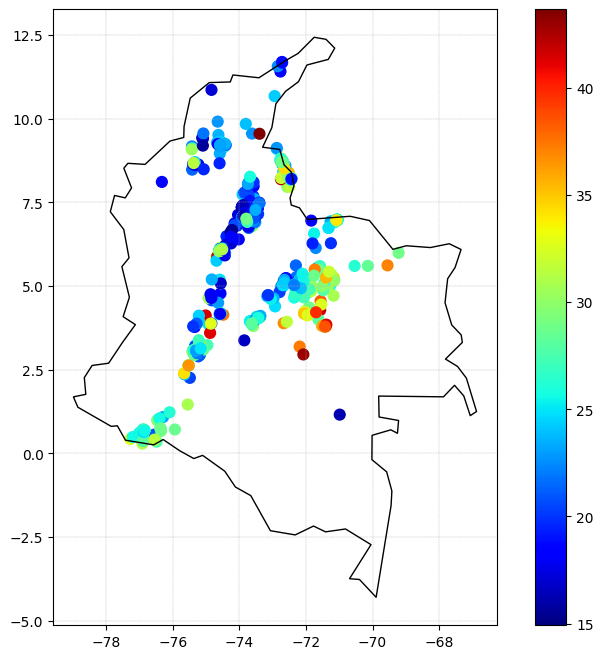

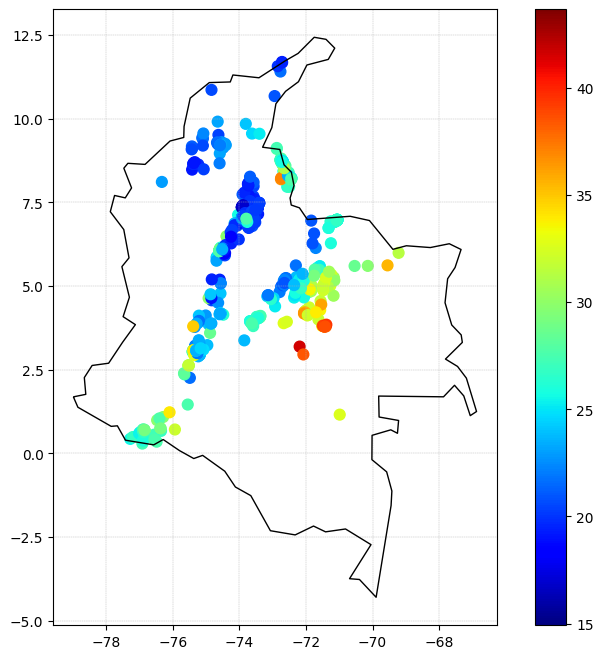

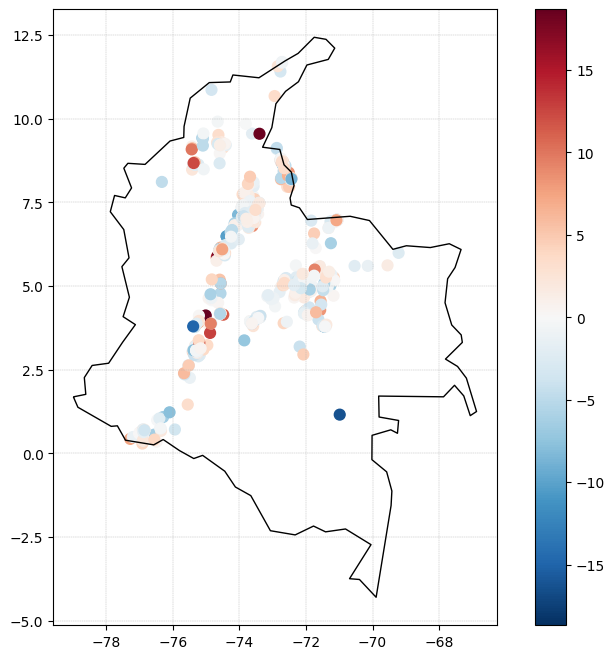

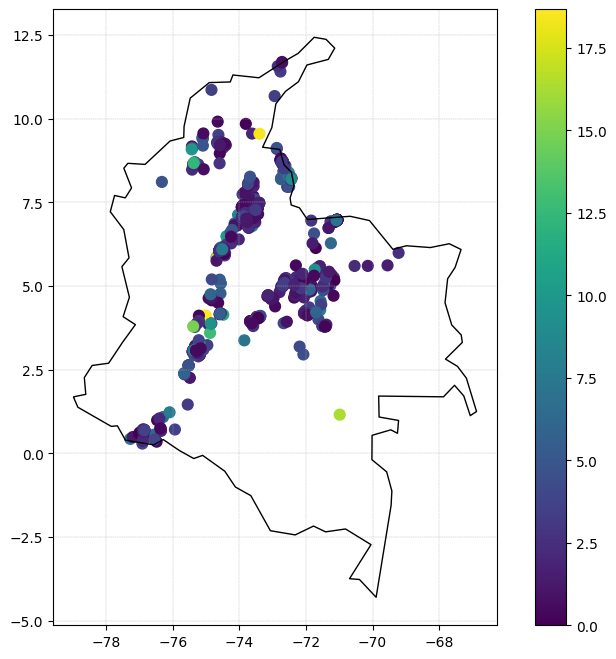

In [18]:
# Cell 13: Mapas espaciales para test


# DataFrame con valores reales
df_pred = pd.DataFrame({
    "ID": ids,
    "actual_real": test_targs_real,
    "pred_real": test_preds_real
})

# GeoDataFrame actual
actual_data = test_df.copy()
actual_data['ID'] = actual_data['ID'].astype(int)
df_pred['ID'] = df_pred['ID'].astype(int)

actual_gdf = gpd.GeoDataFrame(
    actual_data.merge(df_pred[['ID','actual_real','pred_real']], on='ID'),
    geometry=gpd.points_from_xy(
        actual_data['Longitude'],
        actual_data['Latitude']
    ),
    crs="EPSG:4326"
).dropna(subset=['geometry'])

# Predicho
predicted_gdf = actual_gdf.copy()

# Diferencias
actual_col = "actual_real"
pred_col   = "pred_real"

actual_gdf["diff"] = actual_gdf[actual_col] - actual_gdf[pred_col]
actual_gdf["abs_diff"] = np.abs(actual_gdf["diff"])

merged = actual_gdf  # simplificación

# Rangos de colores coherentes
vmin = min(merged[actual_col].min(), merged[pred_col].min())
vmax = max(merged[actual_col].max(), merged[pred_col].max())

vabs = np.nanmax(np.abs(merged["diff"]))
vabs_abs = merged["abs_diff"].max()

# Mapa base Colombia
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

possible_cols = ['iso_a3', 'ISO_A3', 'ADM0_A3', 'SOV_A3']
code_col = next(c for c in possible_cols if c in world.columns)

colombia = world[world[code_col] == 'COL']

minx, miny, maxx, maxy = colombia.total_bounds
padx = (maxx - minx) * 0.05
pady = (maxy - miny) * 0.05
bbox = (minx - padx, maxx + padx, miny - pady, maxy + pady)

def base_map(ax):
    colombia.boundary.plot(ax=ax, linewidth=1.0, color='black')
    ax.set_xlim(bbox[0], bbox[1])
    ax.set_ylim(bbox[2], bbox[3])
    ax.set_aspect('auto')
    ax.grid(True, linestyle='--', linewidth=0.3)

# Mapa actual
fig, ax = plt.subplots(figsize=(10,8))
base_map(ax)
merged.plot(
    ax=ax, column=actual_col, cmap='jet',
    markersize=60, legend=True, vmin=vmin, vmax=vmax
)
fig.savefig("map_actual_REAL.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Mapa predicho
fig, ax = plt.subplots(figsize=(10,8))
base_map(ax)
merged.plot(
    ax=ax, column=pred_col, cmap='jet',
    markersize=60, legend=True, vmin=vmin, vmax=vmax
)
fig.savefig("map_predicted_REAL.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Mapa diferencia
fig, ax = plt.subplots(figsize=(10,8))
base_map(ax)
merged.plot(
    ax=ax, column="diff", cmap='RdBu_r',
    markersize=60, legend=True, vmin=-vabs, vmax=vabs
)
fig.savefig("map_difference_REAL.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Mapa diferencia absoluta
fig, ax = plt.subplots(figsize=(10,8))
base_map(ax)
merged.plot(
    ax=ax, column="abs_diff", cmap='viridis',
    markersize=60, legend=True, vmin=0, vmax=vabs_abs
)
fig.savefig("map_abs_difference_REAL.pdf", dpi=300, bbox_inches="tight")
plt.show()


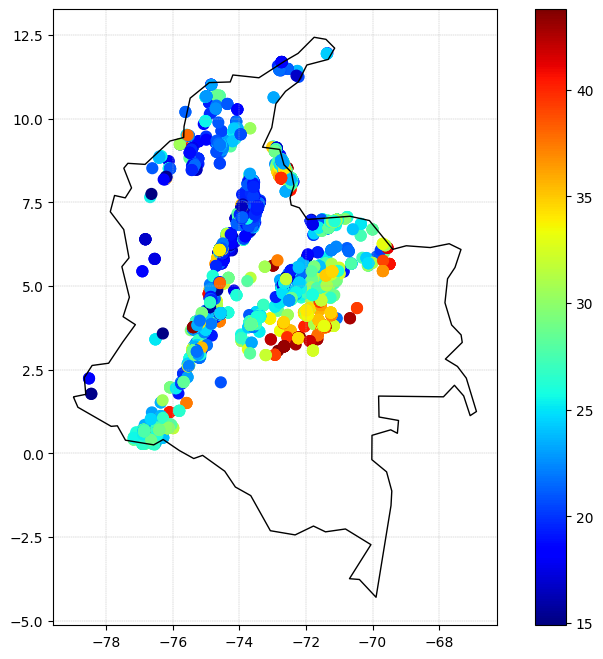

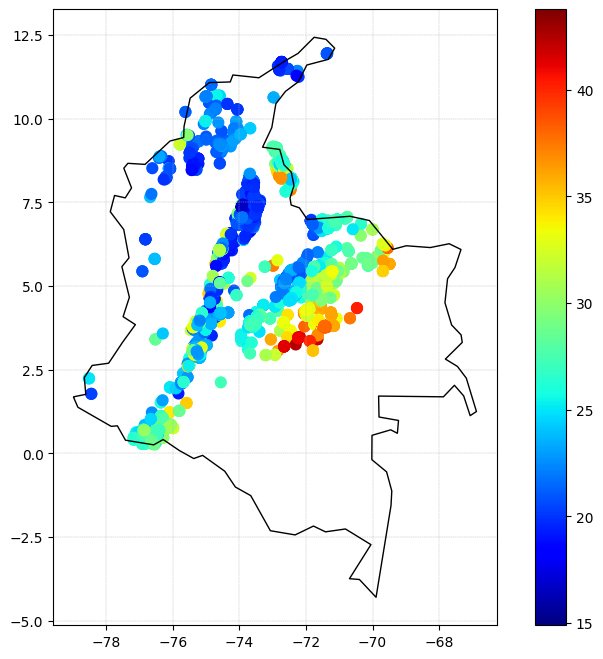

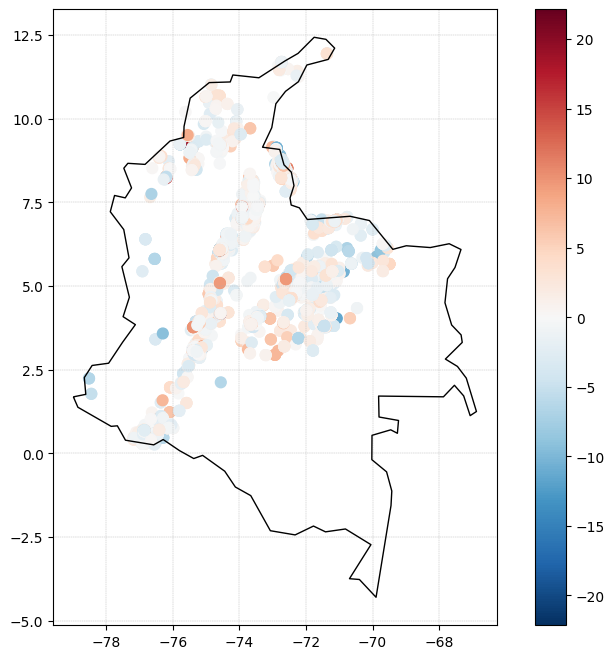

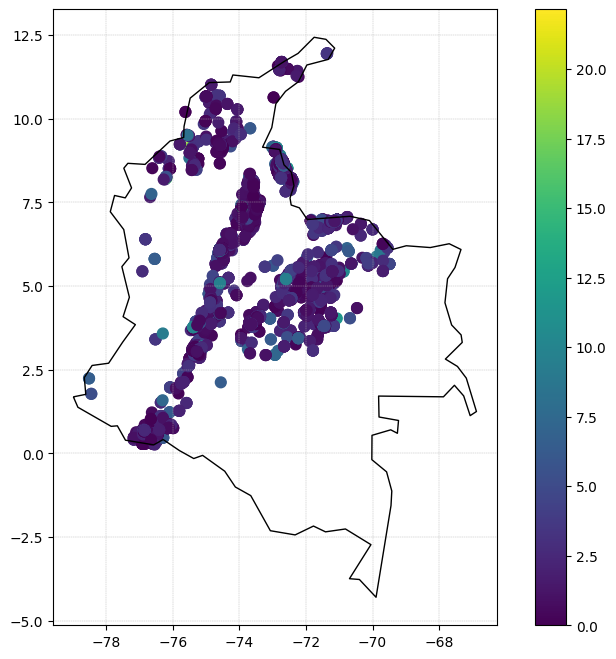

In [19]:
# Cell 14: Mapas espaciales en entrenamiento

# DataFrame con valores reales
df_pred_train = pd.DataFrame({
    "ID": ids_train,
    "actual_real": train_targs_real,
    "pred_real": train_preds_real
})

df_pred_train['ID'] = df_pred_train['ID'].astype(int)

# GeoDataFrame base con coordenadas
actual_data = train_df.copy()
actual_data['ID'] = actual_data['ID'].astype(int)

merged = actual_data.merge(df_pred_train, on='ID')

merged = gpd.GeoDataFrame(
    merged,
    geometry=gpd.points_from_xy(
        merged['Longitude'],
        merged['Latitude']
    ),
    crs="EPSG:4326"
).dropna(subset=['geometry'])

# Diferencias
merged["diff"] = merged["actual_real"] - merged["pred_real"]
merged["abs_diff"] = np.abs(merged["diff"])

# Rangos color consistentes
vmin = min(merged["actual_real"].min(), merged["pred_real"].min())
vmax = max(merged["actual_real"].max(), merged["pred_real"].max())

vabs = np.nanmax(np.abs(merged["diff"]))
vabs_abs = merged["abs_diff"].max()

# Base Colombia
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

possible_cols = ['iso_a3', 'ISO_A3', 'ADM0_A3', 'SOV_A3']
code_col = next(c for c in possible_cols if c in world.columns)

colombia = world[world[code_col] == 'COL']

minx, miny, maxx, maxy = colombia.total_bounds
padx = (maxx - minx) * 0.05
pady = (maxy - miny) * 0.05
bbox = (minx - padx, maxx + padx, miny - pady, maxy + pady)

def base_map(ax):
    colombia.boundary.plot(ax=ax, linewidth=1.0, color='black')
    ax.set_xlim(bbox[0], bbox[1])
    ax.set_ylim(bbox[2], bbox[3])
    ax.set_aspect('auto')
    ax.grid(True, linestyle='--', linewidth=0.3)

# Actual
fig, ax = plt.subplots(figsize=(10,8))
base_map(ax)
merged.plot(
    ax=ax, column="actual_real", cmap='jet',
    markersize=60, legend=True, vmin=vmin, vmax=vmax
)
fig.savefig("map_actual_train_REAL.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Predicho
fig, ax = plt.subplots(figsize=(10,8))
base_map(ax)
merged.plot(
    ax=ax, column="pred_real", cmap='jet',
    markersize=60, legend=True, vmin=vmin, vmax=vmax
)
fig.savefig("map_predicted_train_REAL.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Diferencia
fig, ax = plt.subplots(figsize=(10,8))
base_map(ax)
merged.plot(
    ax=ax, column="diff", cmap='RdBu_r',
    markersize=60, legend=True, vmin=-vabs, vmax=vabs
)
fig.savefig("map_difference_train_REAL.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Diferencia absoluta
fig, ax = plt.subplots(figsize=(10,8))
base_map(ax)
merged.plot(
    ax=ax, column="abs_diff", cmap='viridis',
    markersize=60, legend=True, vmin=0, vmax=vabs_abs
)
fig.savefig("map_abs_difference_train_REAL.pdf", dpi=300, bbox_inches="tight")
plt.show()


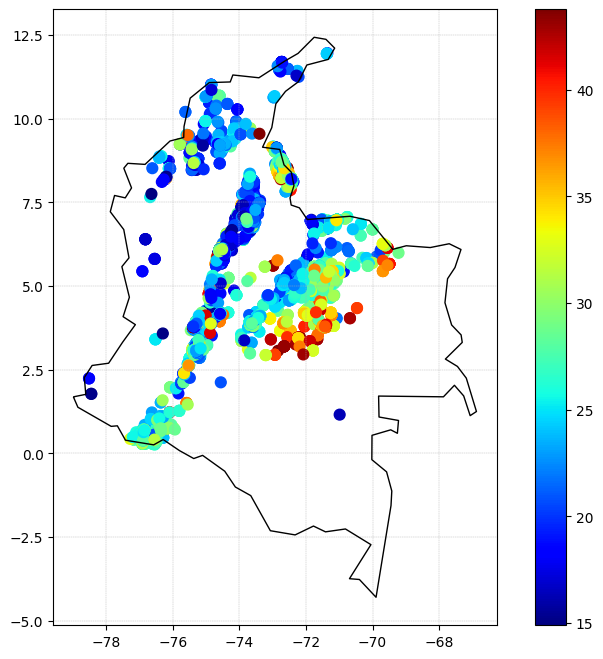

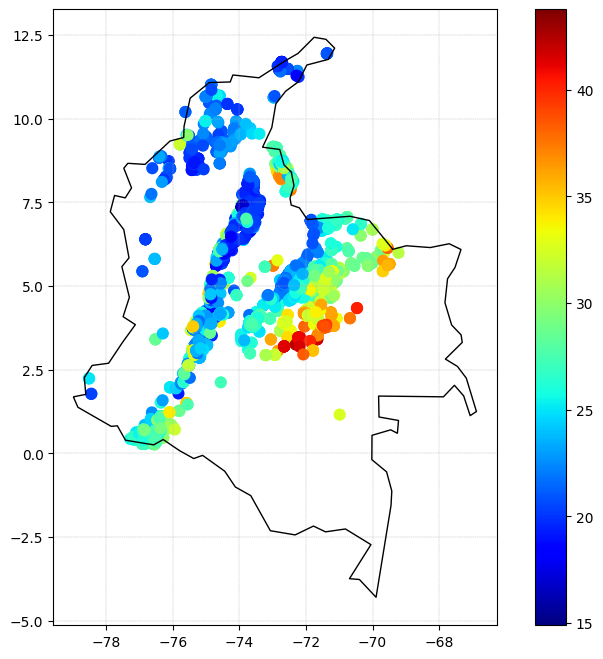

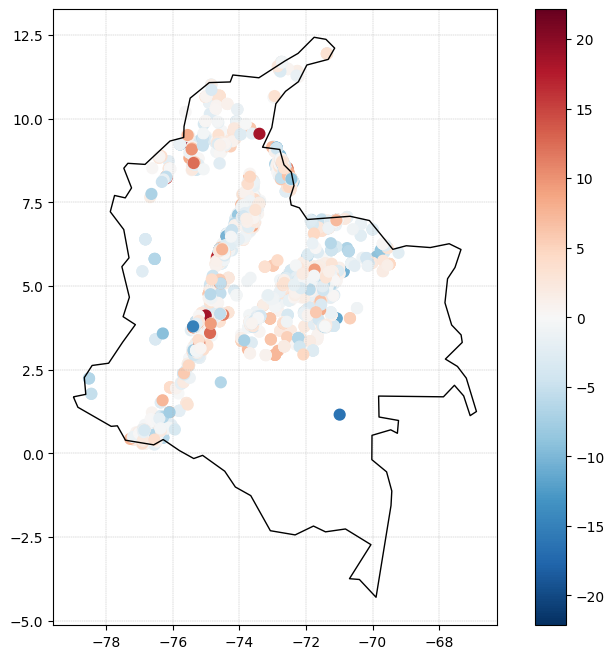

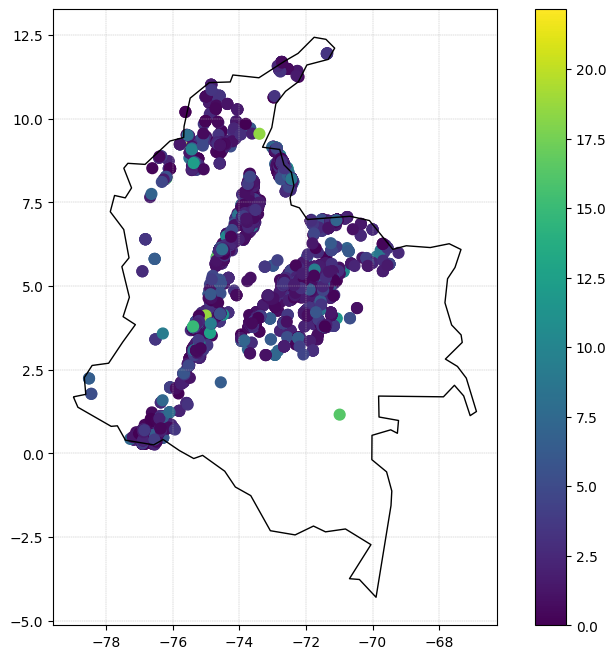

In [20]:
# Cell 15: Mapas espaciales todo el conjunto de datos

# Combinar datasets originales
full_df = pd.concat([train_df, test_df], ignore_index=True)
full_df["ID"] = full_df["ID"].astype(int)

# Combinar predicciones
df_pred_all = pd.concat(
    [
        df_pred_train[["ID", "actual_real", "pred_real"]],
        df_pred[["ID", "actual_real", "pred_real"]]
    ],
    ignore_index=True
)

df_pred_all["ID"] = df_pred_all["ID"].astype(int)

# Merge coords + valores reales
merged = full_df.merge(df_pred_all, on="ID")

merged = gpd.GeoDataFrame(
    merged,
    geometry=gpd.points_from_xy(
        merged['Longitude'],
        merged['Latitude']
    ),
    crs="EPSG:4326"
).dropna(subset=['geometry'])

# Diferencias
merged["diff"] = merged["actual_real"] - merged["pred_real"]
merged["abs_diff"] = np.abs(merged["diff"])

# Rangos color coherentes
vmin = min(merged["actual_real"].min(), merged["pred_real"].min())
vmax = max(merged["actual_real"].max(), merged["pred_real"].max())

vabs = np.nanmax(np.abs(merged["diff"]))
vabs_abs = merged["abs_diff"].max()

# Base Colombia
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

possible_cols = ['iso_a3', 'ISO_A3', 'ADM0_A3', 'SOV_A3']
code_col = next(c for c in possible_cols if c in world.columns)

colombia = world[world[code_col] == 'COL']

minx, miny, maxx, maxy = colombia.total_bounds
padx = (maxx - minx) * 0.05
pady = (maxy - miny) * 0.05
bbox = (minx - padx, maxx + padx, miny - pady, maxy + pady)

def base_map(ax):
    colombia.boundary.plot(ax=ax, linewidth=1.0, color='black')
    ax.set_xlim(bbox[0], bbox[1])
    ax.set_ylim(bbox[2], bbox[3])
    ax.set_aspect('auto')
    ax.grid(True, linestyle='--', linewidth=0.3)

# Actual
fig, ax = plt.subplots(figsize=(10,8))
base_map(ax)
merged.plot(
    ax=ax, column="actual_real", cmap='jet',
    markersize=60, legend=True, vmin=vmin, vmax=vmax
)
fig.savefig("map_actual_FULL_REAL.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Predicho
fig, ax = plt.subplots(figsize=(10,8))
base_map(ax)
merged.plot(
    ax=ax, column="pred_real", cmap='jet',
    markersize=60, legend=True, vmin=vmin, vmax=vmax
)
fig.savefig("map_predicted_FULL_REAL.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Diferencia
fig, ax = plt.subplots(figsize=(10,8))
base_map(ax)
merged.plot(
    ax=ax, column="diff", cmap='RdBu_r',
    markersize=60, legend=True, vmin=-vabs, vmax=vabs
)
fig.savefig("map_difference_FULL_REAL.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Diferencia absoluta
fig, ax = plt.subplots(figsize=(10,8))
base_map(ax)
merged.plot(
    ax=ax, column="abs_diff", cmap='viridis',
    markersize=60, legend=True, vmin=0, vmax=vabs_abs
)
fig.savefig("map_abs_difference_FULL_REAL.pdf", dpi=300, bbox_inches="tight")
plt.show()

TEST REAL -> RMSE=3.650, MAE=2.518, R2=0.508


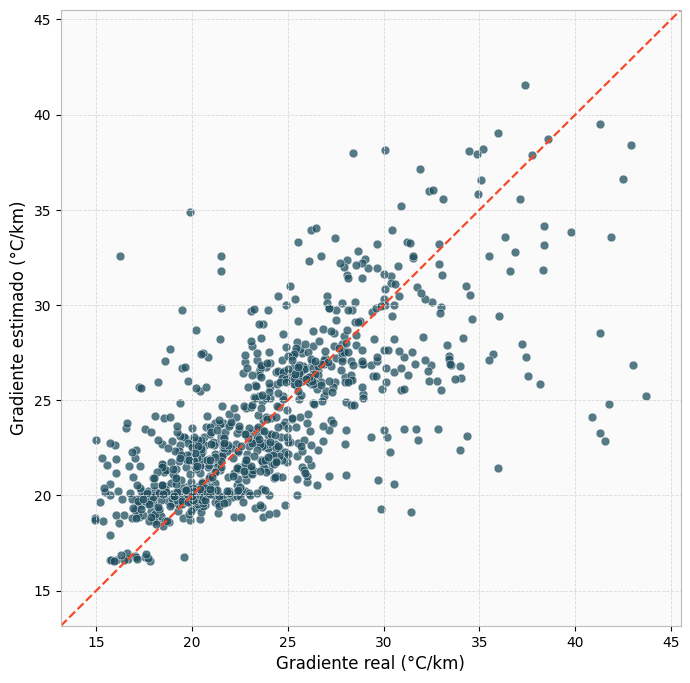

TRAIN REAL -> RMSE=3.201, MAE=2.155, R2=0.673


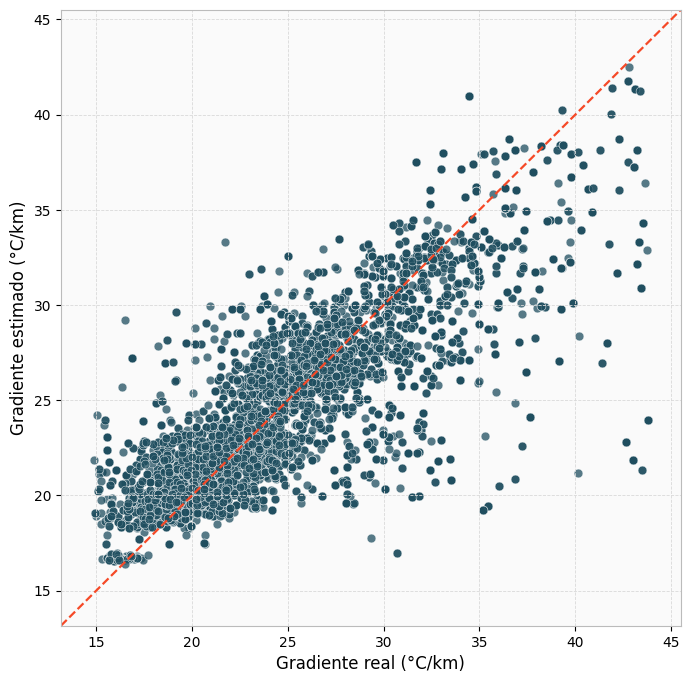

FULL REAL -> RMSE=3.254, MAE=2.196, R2=0.657


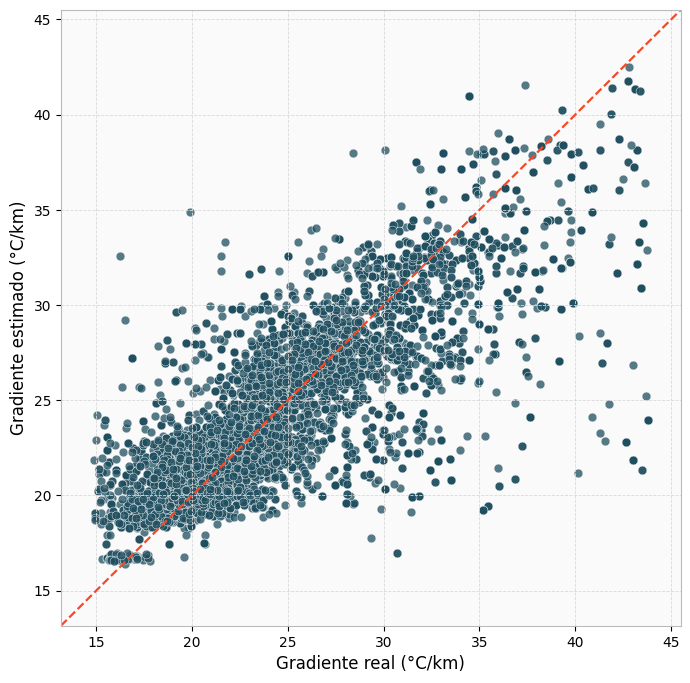

In [21]:
# Cell 17: relación real vs predicho

# Arrays
tp = np.ravel(train_preds_real)
tt = np.ravel(train_targs_real)

ep = np.ravel(test_preds_real)
et = np.ravel(test_targs_real)

full_preds = np.concatenate([tp, ep])
full_targs = np.concatenate([tt, et])

datasets = {
    "TEST": (ep, et),
    "TRAIN": (tp, tt),
    "FULL": (full_preds, full_targs)
}

# Rangos comunes ejes
all_vals = np.concatenate([tp, tt, ep, et])
xmin = np.nanmin(all_vals)
xmax = np.nanmax(all_vals)

pad = (xmax - xmin) * 0.06 if (xmax - xmin) > 0 else 0.5
xlim = (xmin - pad, xmax + pad)
ylim = (xmin - pad, xmax + pad)

# Colores elegantes
point_color = "#1f4e5f"   # azul petróleo
line_color  = "#F54927"   # línea referencia
grid_color  = "#d9d9d9"

# Graficar
for name, (preds, targs) in datasets.items():

    preds = np.ravel(preds)
    targs = np.ravel(targs)

    rmse = np.sqrt(mean_squared_error(targs, preds))
    mae  = mean_absolute_error(targs, preds)
    r2   = r2_score(targs, preds) if len(targs) > 1 else np.nan

    fig, ax = plt.subplots(figsize=(8,8))

    ax.set_facecolor("#fafafa")

    ax.scatter(
        targs, preds,
        s=40,
        alpha=0.75,
        color=point_color,
        edgecolor="white",
        linewidth=0.4
    )

    ax.plot(
        [xlim[0], xlim[1]],
        [xlim[0], xlim[1]],
        linestyle="--",
        color=line_color,
        linewidth=1.6
    )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    ax.set_xlabel("Gradiente real (°C/km)", fontsize=12)
    ax.set_ylabel("Gradiente estimado (°C/km)", fontsize=12)

    ax.grid(True, linestyle="--", linewidth=0.6, color=grid_color)

    for spine in ax.spines.values():
        spine.set_color("#bbbbbb")
        spine.set_linewidth(0.8)

    fname = f"real_vs_estimado_{name.lower()}_REAL.pdf"
    fig.savefig(fname, dpi=300, bbox_inches='tight')

    print(
        f"{name} REAL -> RMSE={rmse:.3f}, "
        f"MAE={mae:.3f}, R2={r2:.3f}"
    )

    plt.show()

In [22]:
!zip -j best_full.zip /content/run_resnet50_attention/best_full.pth
from google.colab import files
files.download("best_full.zip")


	zip warning: name not matched: /content/run_resnet50_attention/best_full.pth

zip error: Nothing to do! (best_full.zip)


FileNotFoundError: Cannot find file: best_full.zip

In [ ]:
!zip -j best_head.zip /content/run_resnet50_attention/best_head.pth
from google.colab import files
files.download("best_head.zip")


In [ ]:
!zip -j best_backbone.zip /content/run_resnet50_attention/best_backbone.pth
from google.colab import files
files.download("best_backbone.zip")